# Human Activity Classification with ConvNeXt and DINOv2

This study compares supervised transfer learning and self-supervised visual
features on 285 still images across **sitting**, **standing**, and
**walking/running**. Model selection is isolated from the fixed 43-image test
split through internal stratified cross-validation.

**Locked result:** OOF-weighted probability blend reached **0.862 macro-F1** and
**0.860 accuracy**. The stratified bootstrap interval for
macro-F1 is **[0.743, 0.954]**, which is reported because
the final test set is deliberately small.

## Evaluation contract

The original train and validation partitions form a 242-image development
pool. All freeze-depth, dropout, augmentation, learning-rate, calibration,
epoch, SVM, and ensemble decisions use out-of-fold predictions from that pool.
The original test partition stays fixed and is evaluated only after the
configuration and downstream-method locks are written.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").is_file():
    raise RuntimeError("Run this notebook from the repository root.")
sys.path.insert(0, str(ROOT / "src"))

from hac.protocol import load_and_validate_manifest  # noqa: E402

sns.set_theme(style="whitegrid", context="notebook")
manifest, protocol = load_and_validate_manifest(
    ROOT / "data" / "manifest.csv", require_images=False
)
pd.DataFrame([{
    "manifest_rows": len(manifest),
    "development_rows": protocol.development_rows,
    "locked_test_rows": protocol.test_rows,
    "manifest_sha256": protocol.manifest_sha256[:12] + "…",
    "test_id_sha256": protocol.test_image_ids_sha256[:12] + "…",
}])

,manifest_rows,development_rows,locked_test_rows,manifest_sha256,test_id_sha256
0,285,242,43,9014ba11dacb…,30a3cd0c4ff9…


## Dataset profile

label,sitting,standing,walking_running
original_split,,,
test,15,14,14
train,66,64,69
val,14,14,15


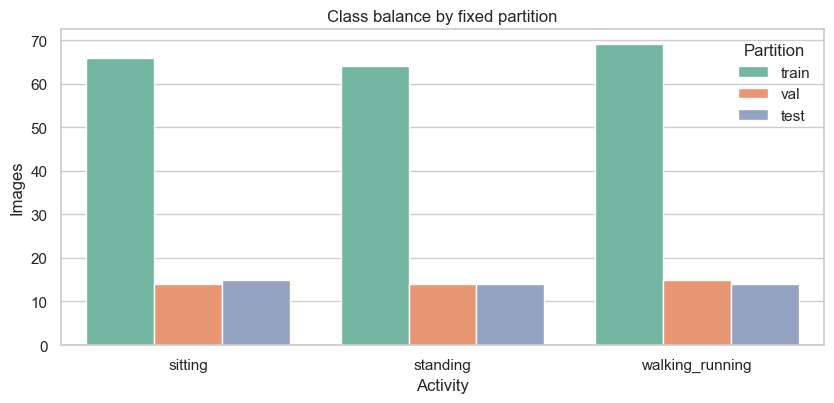

In [2]:
split_counts = (
    manifest.groupby(["original_split", "label"])
    .size()
    .rename("images")
    .reset_index()
)
display(split_counts.pivot(index="original_split", columns="label", values="images"))

fig, ax = plt.subplots(figsize=(8.5, 4.2))
sns.countplot(
    data=manifest,
    x="label",
    hue="original_split",
    order=["sitting", "standing", "walking_running"],
    hue_order=["train", "val", "test"],
    palette="Set2",
    ax=ax,
)
ax.set(xlabel="Activity", ylabel="Images", title="Class balance by fixed partition")
ax.legend(title="Partition", frameon=False)
fig.tight_layout()
plt.show()

The manifest validator checks cardinality, class vocabulary, unique identifiers,
content hashes, and the fixed split contract. It also rejects exact hashes or
perceptual hashes within Hamming distance six when they cross the development
and test boundary. Subject-level independence cannot be claimed because subject
identifiers are not available.

## Controlled regularization screen

,candidate_id,display_model,oof_macro_f1,oof_log_loss,derived_final_epochs
0,conv_randaugment_d10,ConvNeXt-Small,0.7147,0.7726,6
1,conv_base_d0,ConvNeXt-Small,0.7072,0.7802,6
2,conv_base_d10,ConvNeXt-Small,0.7002,0.7315,5
3,conv_last_stage_d10,ConvNeXt-Small,0.6991,0.7593,6
4,conv_mixup_d10,ConvNeXt-Small,0.6963,0.7541,3
5,conv_fixed_val_d10,ConvNeXt-Small,0.6943,0.7519,6
6,conv_head_only_d10,ConvNeXt-Small,0.6932,0.8079,7
7,conv_no_erasing_d10,ConvNeXt-Small,0.6888,0.7735,3
12,dino_full_d10,DINOv2-Small,0.7536,0.7557,4
13,dino_top2_wd5e4_d10,DINOv2-Small,0.7328,0.6782,9


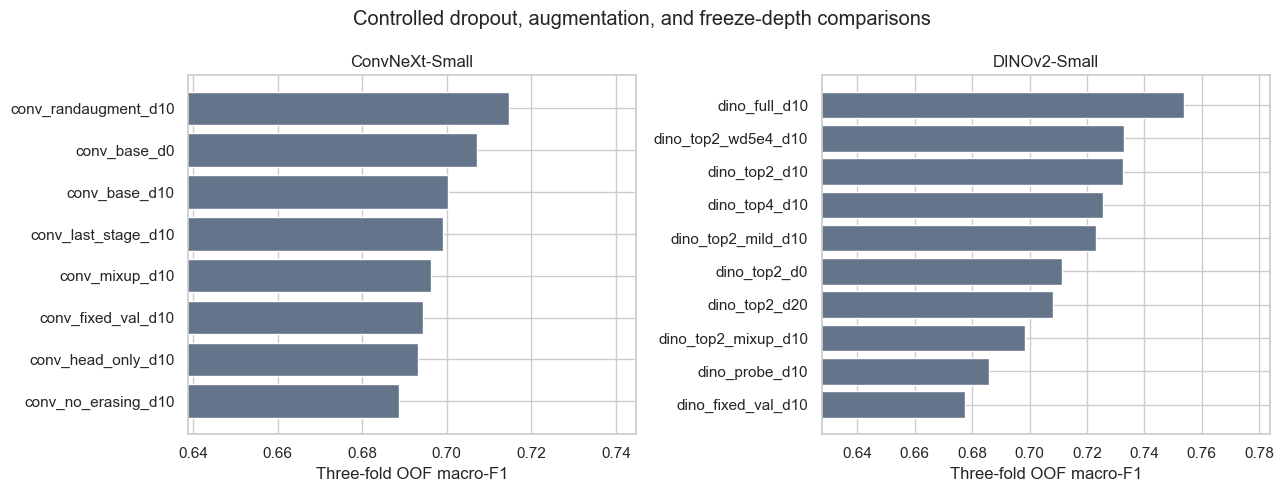

In [3]:
candidates = pd.read_csv(ROOT / "results" / "candidate_selection_summary.csv")
coarse = candidates[candidates["stage"] == "coarse"].copy()
coarse["display_model"] = coarse["model_kind"].map({
    "convnext_small": "ConvNeXt-Small",
    "dinov2_small": "DINOv2-Small",
})
display(
    coarse.sort_values(["model_kind", "oof_macro_f1"], ascending=[True, False])[
        ["candidate_id", "display_model", "oof_macro_f1", "oof_log_loss", "derived_final_epochs"]
    ].round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=False)
for ax, (family, rows) in zip(axes, coarse.groupby("display_model"), strict=True):
    rows = rows.sort_values("oof_macro_f1")
    ax.barh(rows["candidate_id"], rows["oof_macro_f1"], color="#64748B")
    ax.set_title(family)
    ax.set_xlabel("Three-fold OOF macro-F1")
    ax.set_xlim(max(0.0, rows["oof_macro_f1"].min() - 0.05), min(1.0, rows["oof_macro_f1"].max() + 0.03))
fig.suptitle("Controlled dropout, augmentation, and freeze-depth comparisons")
fig.tight_layout()
plt.show()

Interventions are compared independently where possible: head dropout,
full/partial/head-only adaptation, light RandAugment, random-erasing removal,
MixUp, label smoothing, and weight decay. The purpose is not to maximize the
number of regularizers; it is to retain only changes supported by out-of-fold
performance and stability.

## Five-fold confirmation and configuration lock

In [4]:
confirmation = pd.read_csv(ROOT / "results" / "confirmation_ranking.csv")
display(confirmation.round(4))

with (ROOT / "results" / "selection_lock.json").open(encoding="utf-8") as handle:
    selection_lock = json.load(handle)

locked_rows = []
for family, record in selection_lock["selected"].items():
    locked_rows.append({
        "model": family,
        "candidate": record["candidate_id"],
        "confirmation_macro_f1": record["confirmation_oof_macro_f1"],
        "fold_macro_f1_std": record["confirmation_fold_macro_f1_std"],
        **record["config"],
    })
pd.DataFrame(locked_rows).round(5)

,model_kind,rank,candidate_id,oof_macro_f1,fold_macro_f1_std,oof_log_loss,selected
0,convnext_small,1,conv_randaugment_d0,0.7363,0.0454,0.7275,True
1,convnext_small,2,conv_randaugment_d10,0.7317,0.0509,0.7482,False
2,convnext_small,3,conv_base_d0,0.7191,0.0416,0.7503,False
3,convnext_small,4,conv_base_d10,0.7131,0.0377,0.7500,False
4,dinov2_small,1,dino_full_d10,0.8025,0.0394,0.6247,True
5,dinov2_small,2,dino_top2_wd5e4_d10,0.7879,0.0482,0.6240,False
6,dinov2_small,3,dino_top4_d10,0.7812,0.0238,0.6070,False


,model,candidate,confirmation_macro_f1,fold_macro_f1_std,augmentation_strength,batch_size,head_lr,weight_decay,label_smoothing,dropout,mixup_alpha,unfreeze_strategy,backbone_lr
0,convnext_small,conv_randaugment_d0,0.73631,0.04540,mild_randaugment_light,4,0.001,0.0001,0.0,0.0,0.0,full_backbone,0.00003
1,dinov2_small,dino_full_d10,0.80254,0.03939,moderate,4,0.001,0.0001,0.0,0.1,0.0,full_backbone,0.00000


## Locked model architectures

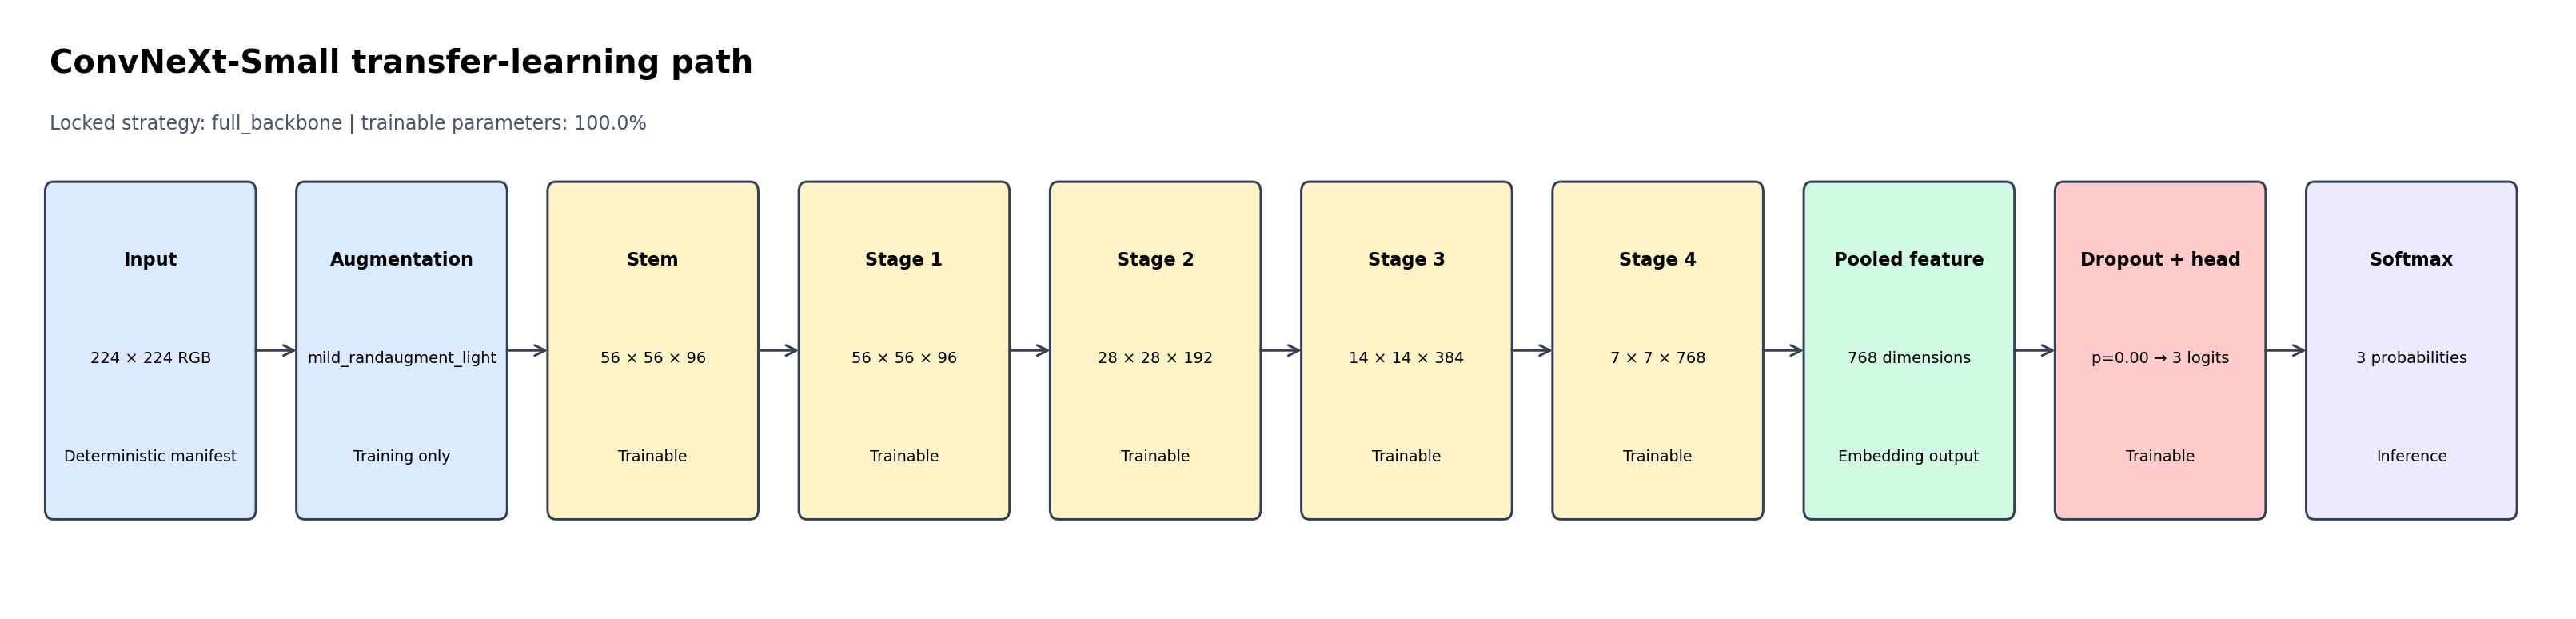

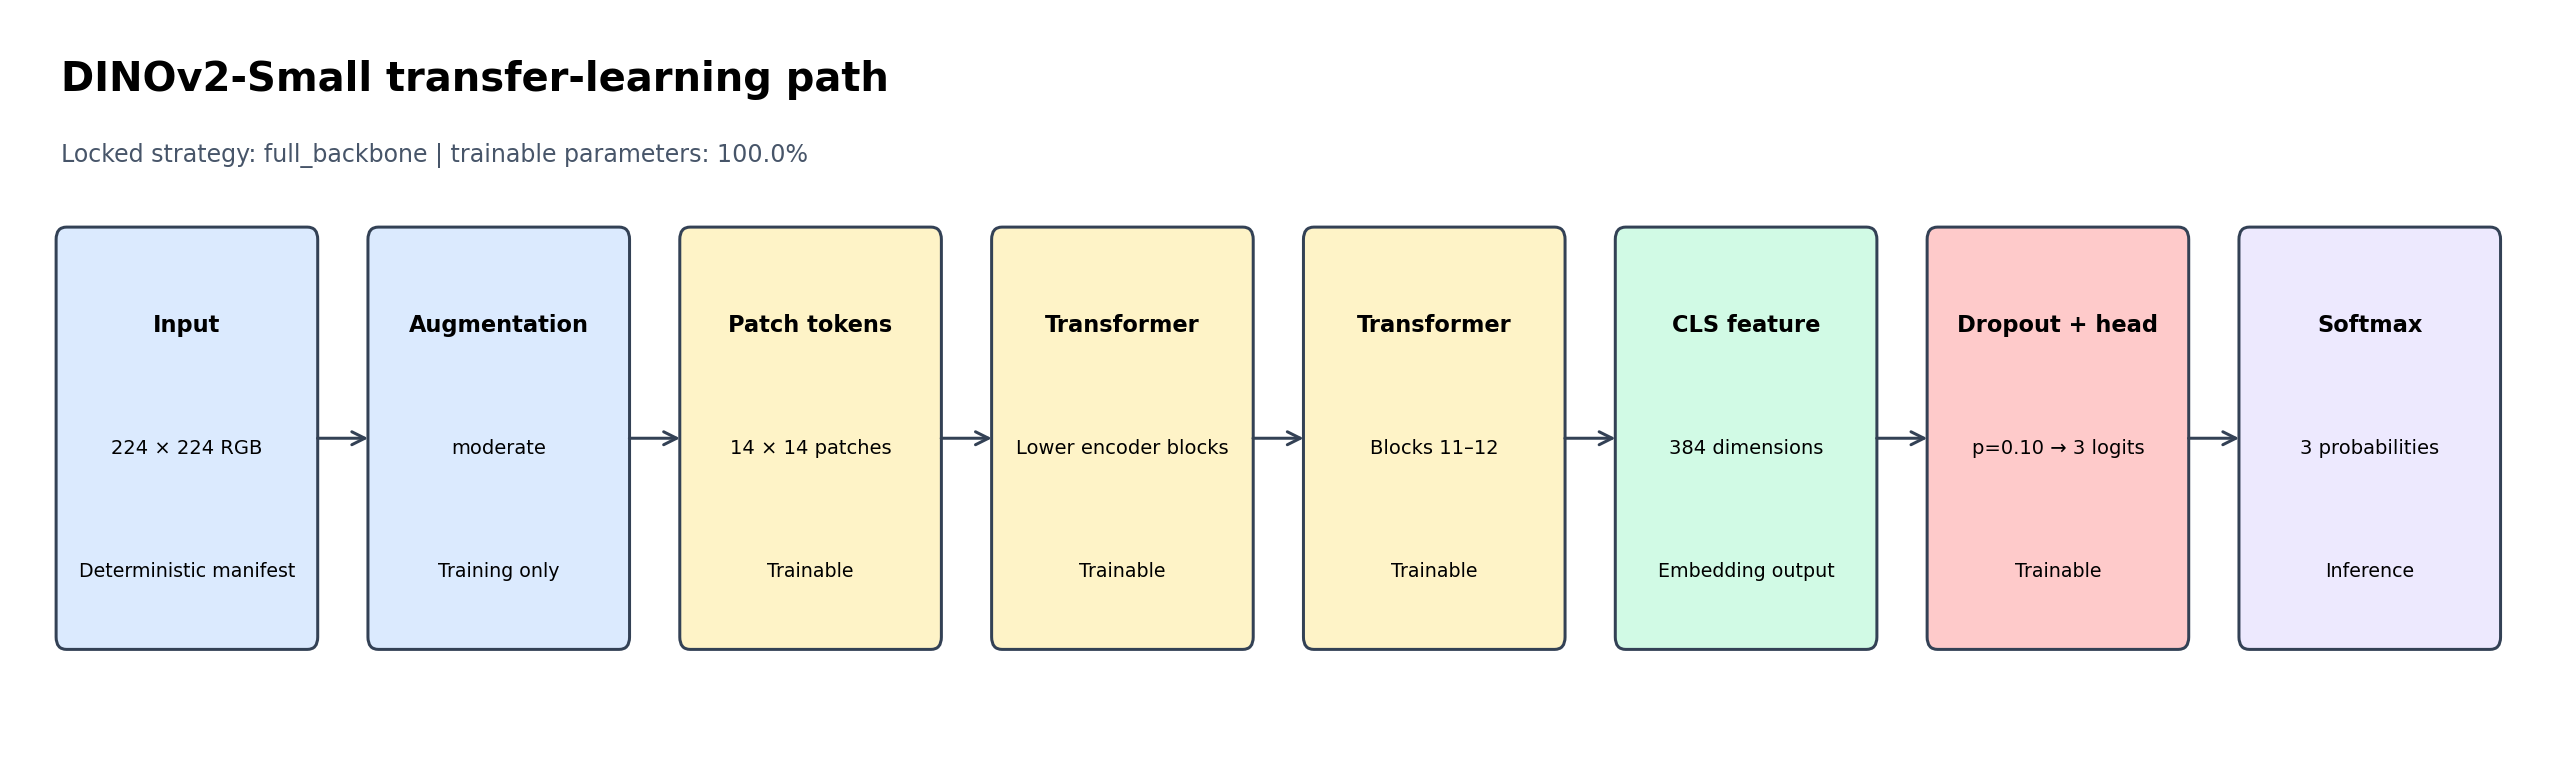

In [5]:
display(Image(filename=str(ROOT / "assets" / "convnext_architecture.png")))
display(Image(filename=str(ROOT / "assets" / "dinov2_architecture.png")))

Each locked configuration is retrained across seeds 42, 52, and 62. Five-fold
training derives a median best-epoch count per seed. Full-pool training replays
the median fold learning-rate state by epoch, avoiding the inherited mismatch
where validation-driven LR reductions disappeared during final retraining.

## Seed stability and calibration

,family,seed,calibration,derived_final_epochs,accuracy,macro_f1,log_loss,ece
1,convnext_small,42,flip_tta_temperature_scaled,5,0.8140,0.8148,0.5058,0.1363
3,convnext_small,42,temperature_scaled,5,0.7907,0.7894,0.5066,0.2266
5,convnext_small,52,flip_tta_temperature_scaled,6,0.7674,0.7703,0.6151,0.1527
7,convnext_small,52,temperature_scaled,6,0.7442,0.7470,0.6175,0.2040
9,convnext_small,62,flip_tta_temperature_scaled,7,0.7674,0.7692,0.6077,0.1202
11,convnext_small,62,temperature_scaled,7,0.7442,0.7477,0.6224,0.1468
13,dinov2_small,42,flip_tta_temperature_scaled,6,0.8140,0.8130,0.5242,0.1119
15,dinov2_small,42,temperature_scaled,6,0.7674,0.7665,0.5264,0.1012
17,dinov2_small,52,flip_tta_temperature_scaled,3,0.8372,0.8348,0.5328,0.1407
19,dinov2_small,52,temperature_scaled,3,0.7907,0.7862,0.5670,0.1384


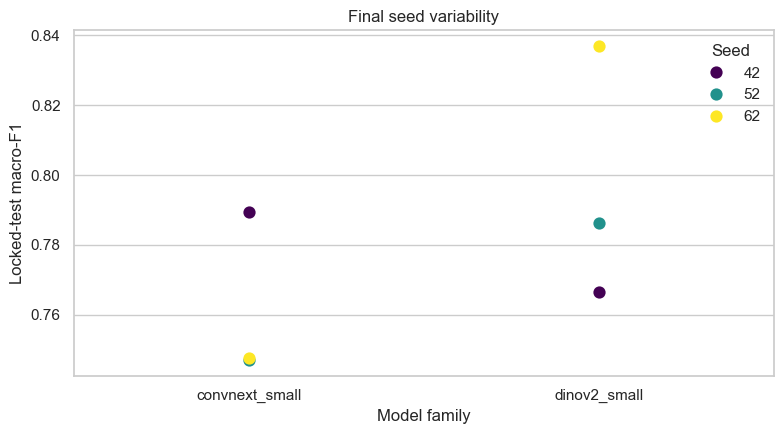

In [6]:
seed_metrics = pd.read_csv(ROOT / "results" / "final_seed_metrics.csv")
primary = seed_metrics[
    seed_metrics["calibration"].isin(["temperature_scaled", "flip_tta_temperature_scaled"])
].copy()
display(
    primary[
        ["family", "seed", "calibration", "derived_final_epochs", "accuracy", "macro_f1", "log_loss", "ece"]
    ].round(4)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.pointplot(
    data=primary[primary["calibration"] == "temperature_scaled"],
    x="family",
    y="macro_f1",
    hue="seed",
    palette="viridis",
    markers="o",
    linestyles="none",
    ax=ax,
)
ax.set(xlabel="Model family", ylabel="Locked-test macro-F1", title="Final seed variability")
ax.legend(title="Seed", frameon=False)
fig.tight_layout()
plt.show()

## OOF-locked downstream selection

In [7]:
policy = pd.read_csv(ROOT / "results" / "evaluation_policy_oof_selection.csv")
ranking = pd.read_csv(ROOT / "results" / "downstream_oof_ranking.csv")
display(policy.round(4))
display(ranking.round(4))

,family,policy,macro_f1,log_loss,prefer_simpler,selected
0,convnext_small,center_plus_horizontal_flip,0.7426,0.6583,1,True
1,convnext_small,center_crop,0.7348,0.6634,0,False
2,dinov2_small,center_crop,0.7808,0.5479,0,True
3,dinov2_small,center_plus_horizontal_flip,0.7778,0.5478,1,False


,method,accuracy,macro_f1,weighted_f1,balanced_accuracy,log_loss,brier_score,ece,oof_rank,selected_champion
0,probability_blend,0.7893,0.7882,0.7894,0.7882,0.5504,0.3159,0.0970,1,True
1,dinov2_small,0.7810,0.7808,0.7820,0.7802,0.5479,0.3162,0.0816,2,False
2,dinov2_small_svm,0.7727,0.7723,0.7736,0.7714,0.5261,0.3098,0.0540,3,False
3,convnext_small,0.7438,0.7426,0.7437,0.7429,0.6583,0.3793,0.0686,4,False
4,convnext_small_svm,0.7397,0.7390,0.7408,0.7379,0.6552,0.3794,0.0900,5,False


The downstream comparison includes calibrated seed averages, an OOF-weighted
ConvNeXt/DINOv2 probability blend, and SVM probes over OOF embeddings. A
center-crop versus center-plus-horizontal-flip policy is also selected per
family using OOF predictions. The test set does not determine any of these
choices.

## Locked test results

,display_name,selected_champion,accuracy,macro_f1,balanced_accuracy,log_loss,ece
0,OOF-weighted probability blend,True,0.8605,0.8618,0.8603,0.4928,0.1710
1,DINOv2-Small,False,0.8605,0.8618,0.8603,0.4993,0.1721
2,DINOv2 + RBF/linear SVM,False,0.8605,0.8618,0.8603,0.5167,0.1411
3,ConvNeXt-Small,False,0.8140,0.8154,0.8143,0.5327,0.1653
4,ConvNeXt + RBF/linear SVM,False,0.8140,0.8154,0.8143,0.6198,0.0918


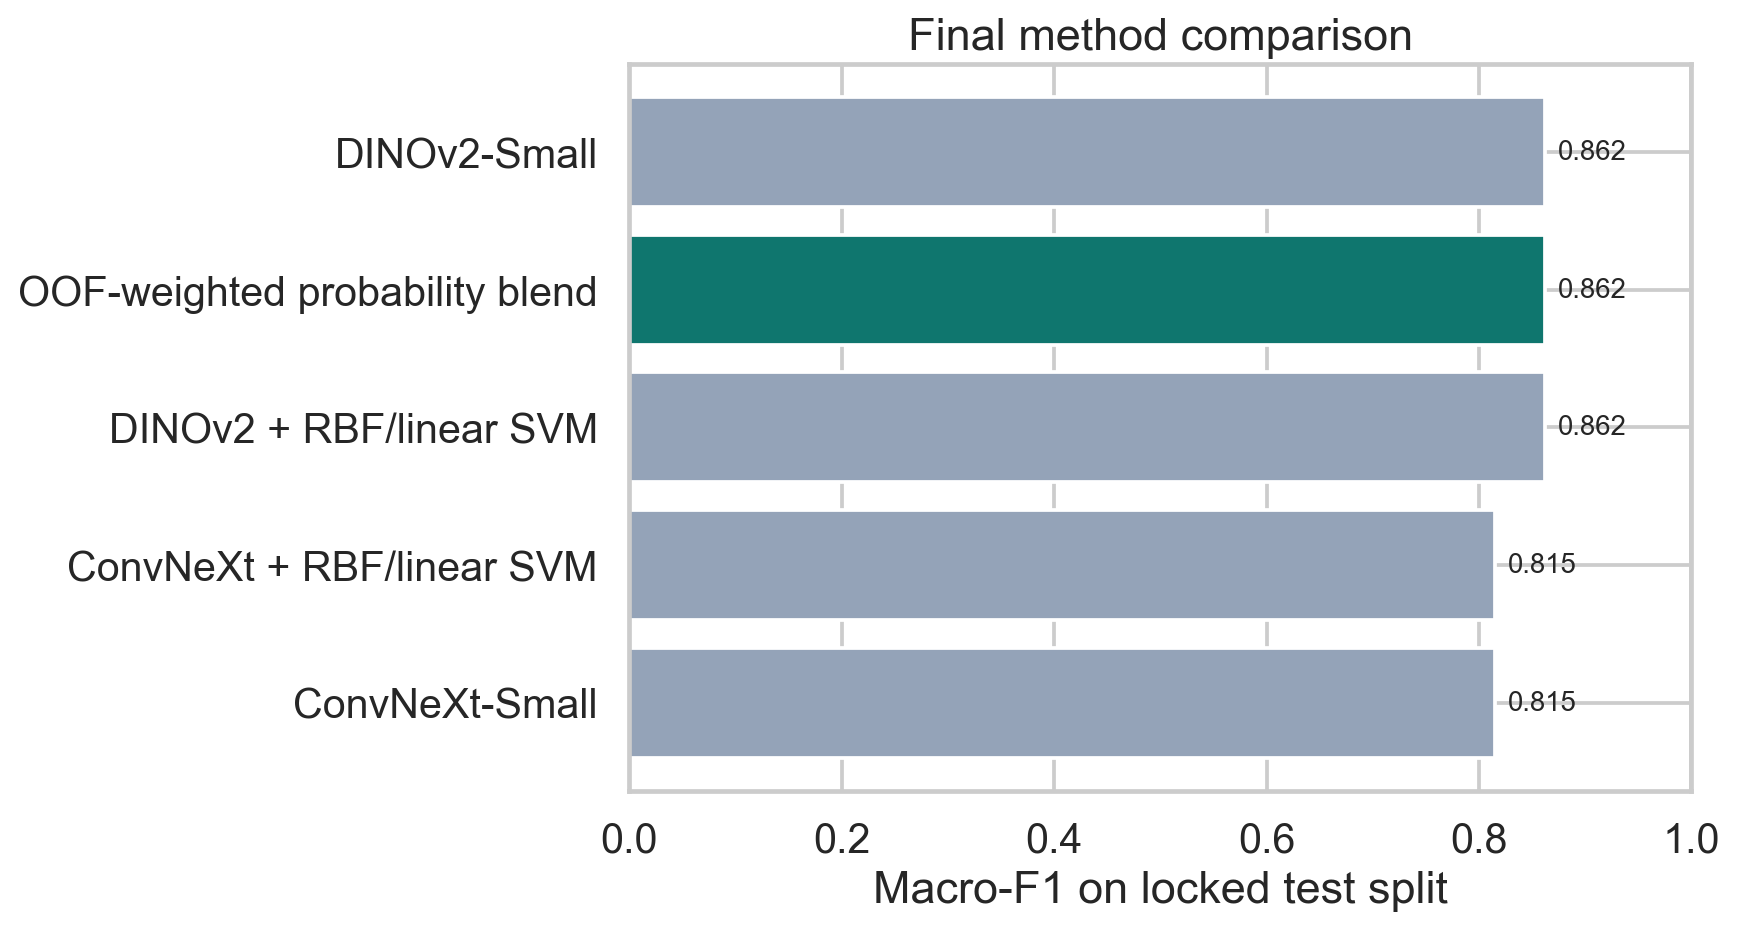

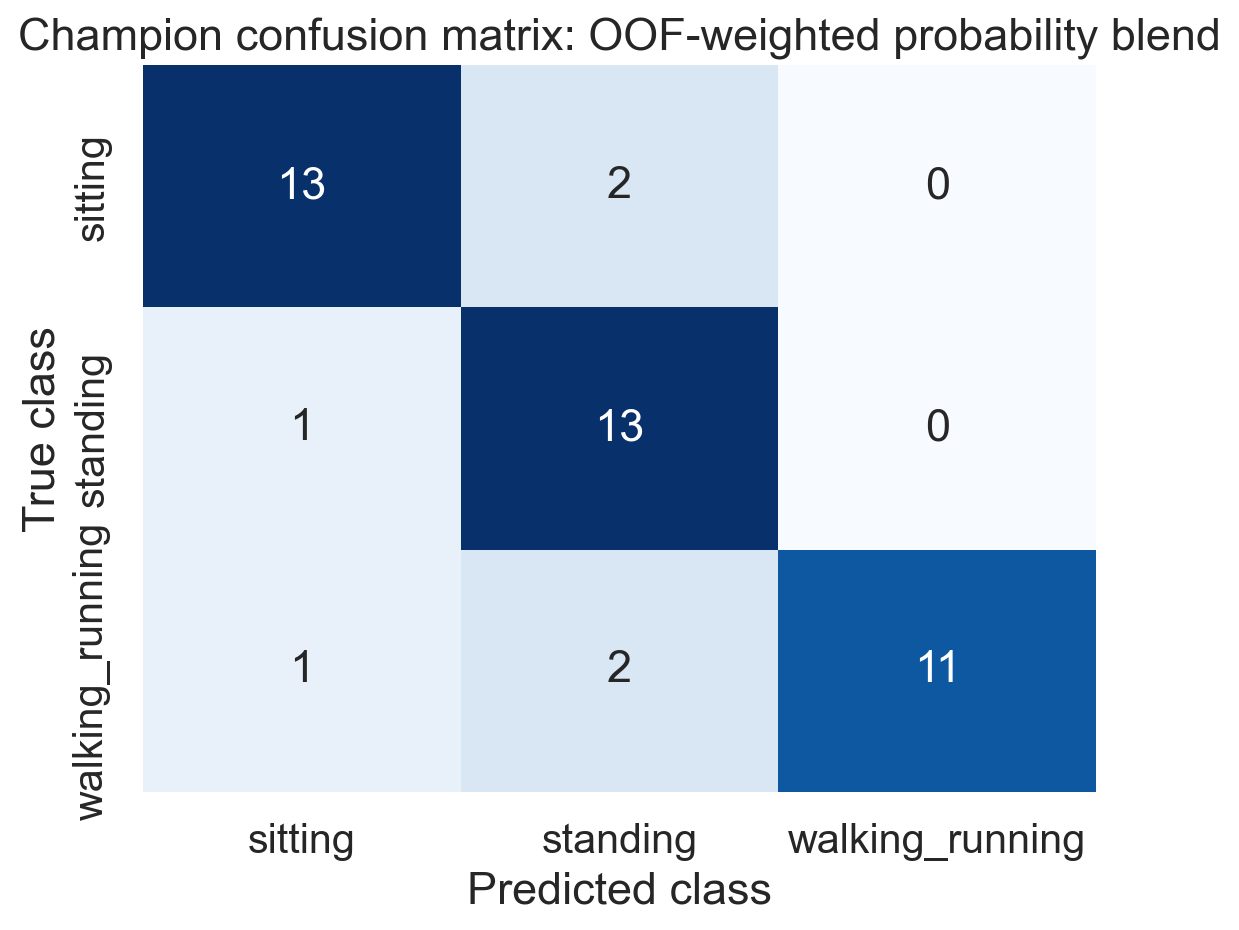

In [8]:
test_metrics = pd.read_csv(ROOT / "results" / "locked_test_metrics.csv")
display(
    test_metrics[
        ["display_name", "selected_champion", "accuracy", "macro_f1", "balanced_accuracy", "log_loss", "ece"]
    ].round(4)
)
display(Image(filename=str(ROOT / "assets" / "final_method_comparison.png")))
display(Image(filename=str(ROOT / "assets" / "champion_confusion_matrix.png")))

## Error inspection

,image_id,true_class,predicted_class,confidence,image_url
0,222118,standing,sitting,0.932,http://images.cocodataset.org/val2017/00000022...
1,394199,sitting,standing,0.718,http://images.cocodataset.org/val2017/00000039...
2,232563,walking/running,standing,0.502,http://images.cocodataset.org/val2017/00000023...
3,333745,walking/running,standing,0.487,http://images.cocodataset.org/val2017/00000033...
4,210388,walking/running,sitting,0.456,http://images.cocodataset.org/val2017/00000021...
5,213547,sitting,standing,0.403,http://images.cocodataset.org/val2017/00000021...


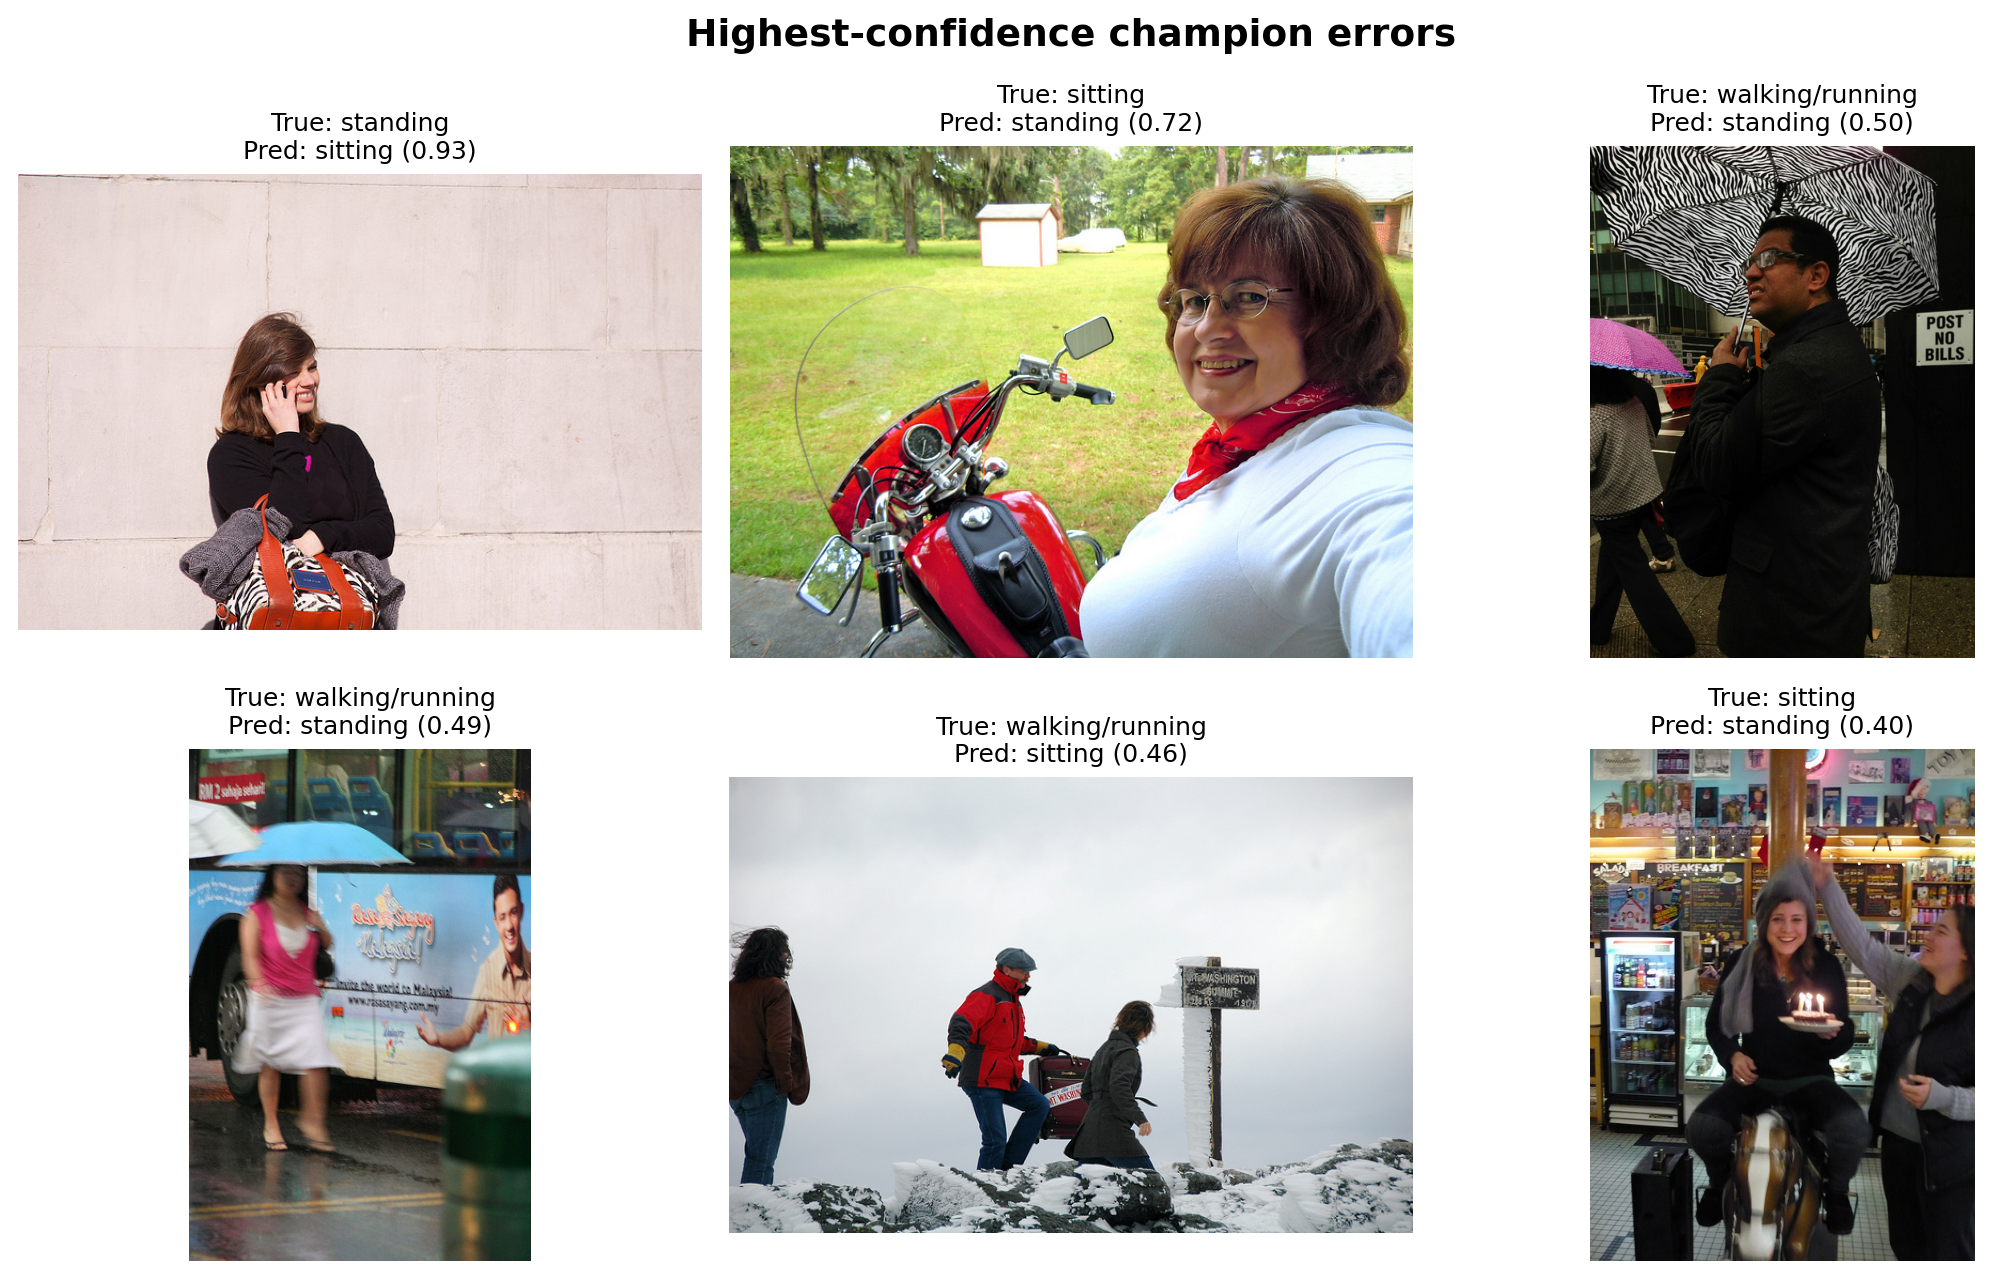

In [9]:
errors = pd.read_csv(ROOT / "results" / "champion_error_analysis.csv")
display(
    errors[
        ["image_id", "true_class", "predicted_class", "confidence", "image_url"]
    ].round(3)
)
display(Image(filename=str(ROOT / "assets" / "champion_error_gallery.png")))

This gallery is diagnostic only and is generated after the downstream lock.
No test image is relabeled, removed, or used to revise the selected method.

## Uncertainty and paired comparison

In [10]:
intervals = pd.read_csv(ROOT / "results" / "test_bootstrap_intervals.csv")
differences = pd.read_csv(ROOT / "results" / "champion_paired_bootstrap_difference.csv")
display(intervals[intervals["metric"] == "macro_f1"].round(4))
display(differences.round(4))

,method,metric,bootstrap_mean,ci_2_5,ci_97_5,resamples
1,convnext_small,macro_f1,0.8129,0.6916,0.9094,2000
3,dinov2_small,macro_f1,0.8602,0.7452,0.9539,2000
5,convnext_small_svm,macro_f1,0.8129,0.6916,0.9094,2000
7,dinov2_small_svm,macro_f1,0.8589,0.7429,0.9539,2000
9,probability_blend,macro_f1,0.8595,0.7429,0.9539,2000


,champion,reference,metric,mean_difference,ci_2_5,ci_97_5,probability_difference_gt_zero,resamples
0,probability_blend,dinov2_small,accuracy,-0.0004,-0.0698,0.0698,0.352,2000
1,probability_blend,dinov2_small,macro_f1,-0.0007,-0.0735,0.0700,0.431,2000


## Conclusion

The OOF selection process chose **OOF-weighted probability blend** (`probability_blend`) as the
portfolio headline. Its fixed-test result is **0.862 macro-F1** and
**0.860 accuracy**. This replaces the notebook's conflicting
historical outputs with one traceable lineage: a fixed test contract, explicit
configuration locks, three final seeds, OOF calibration, and paired uncertainty
reporting.

The small test set limits precision, and the lack of subject identifiers limits
the generalization claim. Results should be read as a careful benchmark on this
manifest, not as a deployment guarantee.

## Reproduction

1. Install the project and notebook dependencies from `pyproject.toml`.
2. Download the checksum-verified images with
   `python tools/download_dataset.py --manifest data/manifest.csv`.
3. Review `docs/EXPERIMENT_PROTOCOL.md` and the tracked configuration locks.
4. Run the training scripts from the repository root. Bulky checkpoints and
   local experiment artifacts stay under `.runs/` and are intentionally not
   committed.

The tracked results are sufficient to rerun this analysis notebook without
downloading model checkpoints or the source images.